We will now look at adding the sun forcer to the coupled system. K is still the same for all

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter
import math
import cmath

In [2]:
#defined parameters that don't need function
#make functions for other parameters
#randomly generat the data at t=0
#get data over time
#plot 

In [4]:
def make_omega_array(N):
    omega_array = np.random.normal(0, 1, N)
    return omega_array

In [5]:
def make_theta_array(N):
    theta_array = np.random.uniform(-np.pi, np.pi, N)
    return theta_array

In [23]:
K=3 #Coupling strength
N=500 #Number of oscillator
A=0.1 #Forcing strength
number_time_steps=500 #Number of time steps
time_step=0.01 
Omega=2*np.pi/24 #Natural frequency of sun in hours
omega_array=make_omega_array(N)#makes array of oscillators natural frequencies
theta_array=make_theta_array(N)#makes array of oscillator phases

In [24]:
#print(omega_array, theta_array)

#### Functions

In [25]:
#the rhs calculation
def forced_kuramoto(theta_array, omega_array, K, N, A, Omega):
    theta_dot = np.zeros(N)
    sum_cisj=0
    for j in range(N):
        sum_cisj+=math.cos(theta_array[j])+1j*math.sin(theta_array[j])
    z=(1/N)*sum_cisj
    for i in range(N):
        complex_sum_replacement=K*z*(math.cos(theta_array[i])-1j*math.sin(theta_array[i]))
        img_sum_replacement=complex_sum_replacement.imag
        theta_dot[i] = (omega_array[i]-Omega) + img_sum_replacement - A * math.sin(theta_array[i])

    return theta_dot

In [26]:
rhs=forced_kuramoto(theta_array, omega_array, K, N, A, Omega)
#print(rhs)

In [27]:
def runge_kutta_4th_order(theta_array, omega_array, K, N, A, Omega, delta_t):
    k1= forced_kuramoto(theta_array, omega_array, K, N, A, Omega)*delta_t
    k2= forced_kuramoto(theta_array + 0.5*k1, omega_array, K, N, A, Omega)*delta_t
    k3= forced_kuramoto(theta_array + 0.5*k2, omega_array, K, N, A, Omega)*delta_t
    k4= forced_kuramoto(theta_array + k3, omega_array, K, N, A, Omega,)*delta_t
    
    theta_array_plustimestep = theta_array + (1/6)*(k1 + 2*k2 + 2*k3 + k4)
    
    return theta_array_plustimestep

In [28]:
def runge_kutta_loop(theta_array, omega_array, K, N, A, Omega, delta_t, total_T):
    
    theta_history = np.zeros((total_T, len(theta_array)))
    theta_history[0] = theta_array
    
    for i in range(1, total_T):
        theta_history[i] = runge_kutta_4th_order(theta_history[i-1], omega_array, K, N, A, Omega, delta_t)

    return theta_history

In [29]:
theta_history=runge_kutta_loop(theta_array, omega_array, K, N, A, Omega, time_step, number_time_steps)
#print(theta_history)

In [30]:
time=np.arange(number_time_steps)

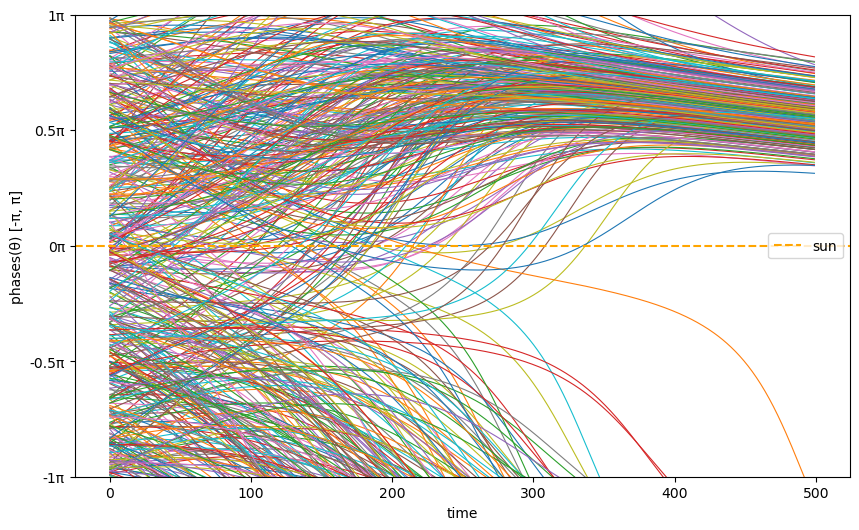

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot theta_history (assuming it's already defined)
for i in range(theta_history.shape[1]):  # loop over columns
    ax.plot(time, theta_history[:, i], lw=0.8)

# Horizontal line at y = 0
ax.axhline(
    y=0,
    color='orange',
    linestyle='--',
    linewidth=1.5,
    label='sun'
)

# Set y-axis limits to -pi to pi
ax.set_ylim(-np.pi, np.pi)

# Set tick spacing (π/2)
ax.yaxis.set_major_locator(MultipleLocator(np.pi/2))

# Format ticks as multiples of π
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda val, pos: f"{val/np.pi:.1g}π")
)

# Labels and legend
ax.set_xlabel('time')
ax.set_ylabel('phases(θ) [-π, π]')
ax.legend()

# Show plot
plt.show()

In [32]:
def calculate_order_parameter_rhs(N, theta_history, timestep):
    # 1/N sum from l=1 to N cos(theta_l) + isin(theta_l)
    theta_l_sum = 0
    for i in range(N):
        theta_l = theta_history[timestep, i]
        theta_l_sum += math.cos(theta_l)+ 1j*math.sin(theta_l)
    order_parameter_rhs = (1/N)*theta_l_sum
    return order_parameter_rhs

In [33]:
def calculate_order_parameter_lhs(order_parameter_rhs): 
    #R(t) e^(i PSi(t)=order_paramter_rhs=Z(t)
    #R is magnitude of Z(t)
    #Psi(t) is the argument of Z(t)        Re(z)=|z|cos(arg)  Re(z)/|z|=cos(arg)    cos^-1( Re(z)/|z|)=arg?
    #e^iPsi(t)= cos(Psi(t))+ i sin(Psi(t))
    re = order_parameter_rhs.real
    im = order_parameter_rhs.imag
    R = math.sqrt(re**2 + im**2)
    Psi = cmath.phase(order_parameter_rhs)
    return R, Psi

In [34]:
def substract_average_phase(N, theta_history, Psi):
    theta_history=theta_history-Psi
    return theta_history

In [35]:
def complexify_phases_for_unit_circle(theta_history, N, timestep):
    complexified_theta_history = np.zeros((N, 2))
    for i in range(N):
        complexified_theta_history[i,0] = math.cos(theta_history[timestep,i])
        complexified_theta_history[i,1] = math.sin(theta_history[timestep,i])
    return complexified_theta_history

In [36]:
def plot_at_one_time(R, Psi, complexified_theta_test, time):
    x = complexified_theta_test[:, 0]
    y = complexified_theta_test[:, 1]
    
    # plot the unit circle
    theta = np.linspace(-np.pi, np.pi, 200)
    circle_x = np.cos(theta)
    circle_y = np.sin(theta)
    
    plt.figure(figsize=(6,6))
    plt.plot(circle_x, circle_y, 'k--', label='unit circle')  # optional: dashed unit circle
    plt.scatter(x, y, color='blue', s=50, label='oscillators')
    plt.text(-1, 1.05, f'R ≈ {R:.2f}', fontsize=12)
    plt.text(-1, 0.95, f'Ψ ≈ {Psi:.2f}', fontsize=12)
    plt.text(-1, 0.85, f't = {time:.2f}', fontsize=12)
    if(R-0.1>0):
        R=R-0.1
    if(R>1):
        R=1
    plt.arrow(0, 0, R-0.01, 0, color='black', width=0.02, label='R vector')
    
    plt.scatter(1,0, color="orange", s=100)
    
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlim([-1.2, 1.2])
    plt.ylim([-1.2, 1.2])
    plt.xlabel('cos(θ)')
    plt.ylabel('sin(θ)')
    plt.title('Oscillator Phases on Unit Circle')
    #plt.legend()
    plt.show()

In [37]:
def plot_over_time(N, total_time, test_theta_history, plot_every=50) :
    #print(test_theta_history)
    #print("______________")
    for i in range(total_time):
        order_parameter_rhs = calculate_order_parameter_rhs(N, test_theta_history, i)
        #print(order_parameter_rhs)
        R, Psi = calculate_order_parameter_lhs(order_parameter_rhs)
        #print(R,Psi)
        #theta_history_minus_Psi=substract_average_phase(N, test_theta_history, Psi)
        #print(theta_history_minus_Psi)
        complexified_theta_test = complexify_phases_for_unit_circle(theta_history, N, i)
        #print("______________")
        #print(complexified_theta_test)
        if(i%plot_every==0 or i==total_time-1):
            plot_at_one_time(R, Psi, complexified_theta_test, i)
        

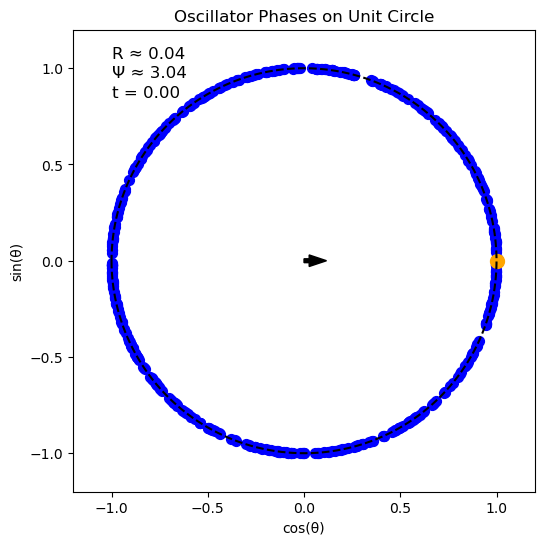

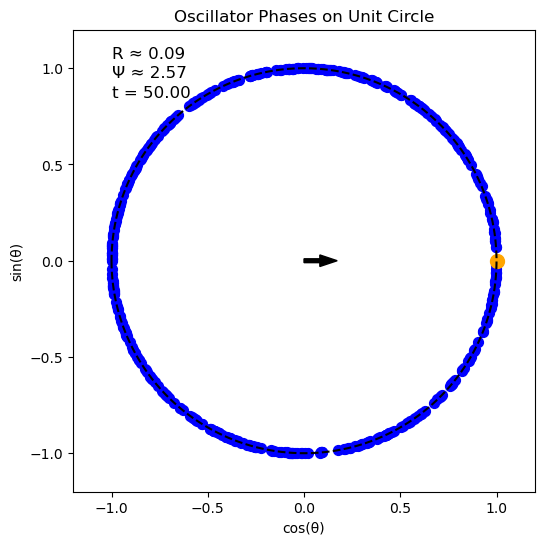

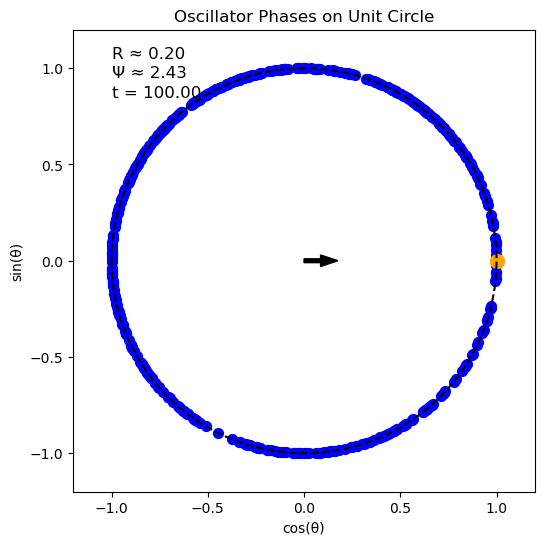

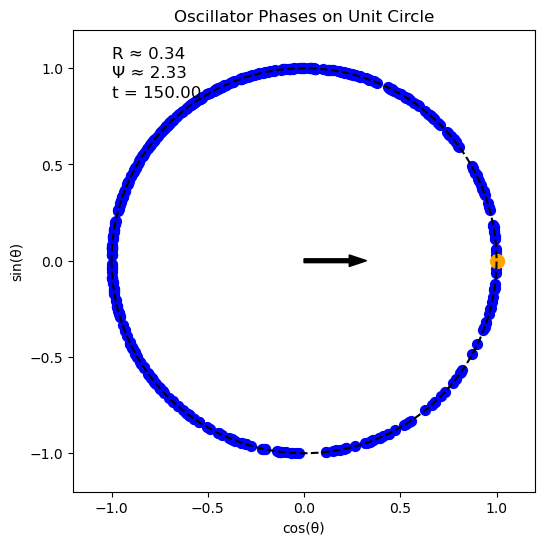

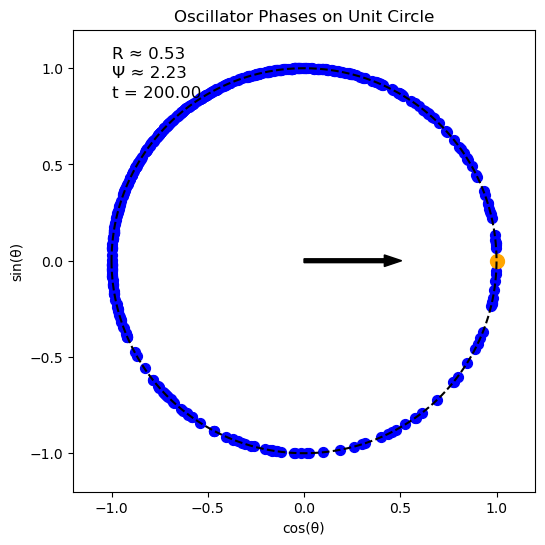

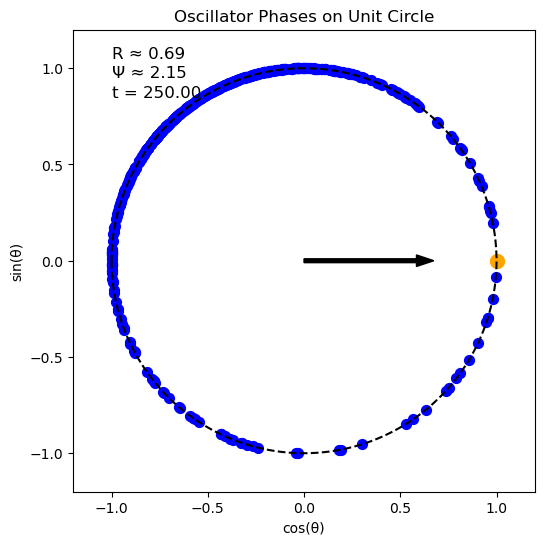

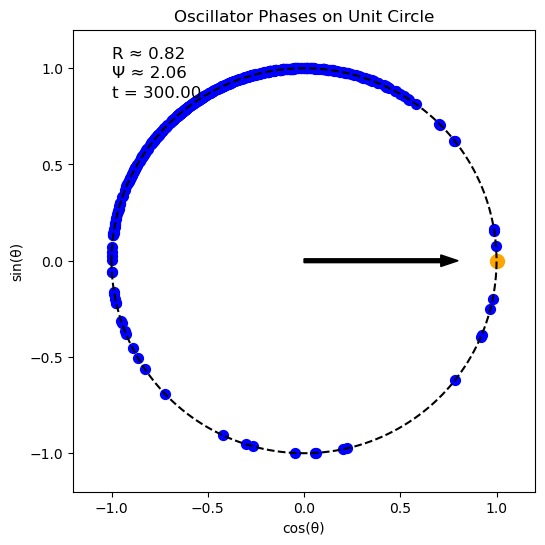

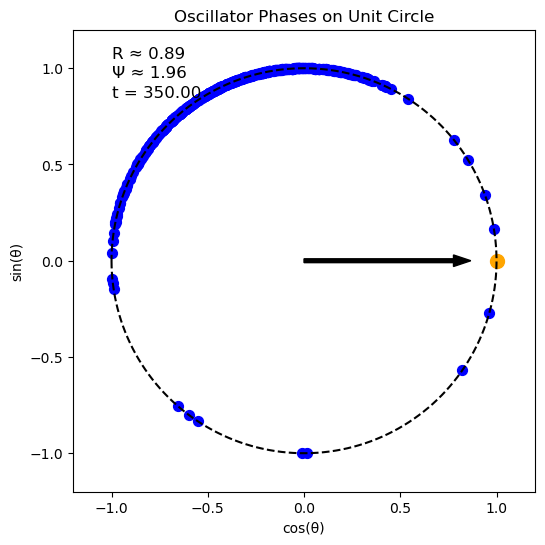

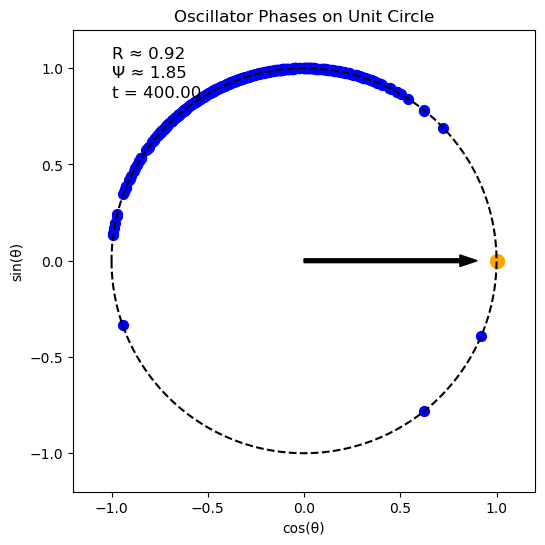

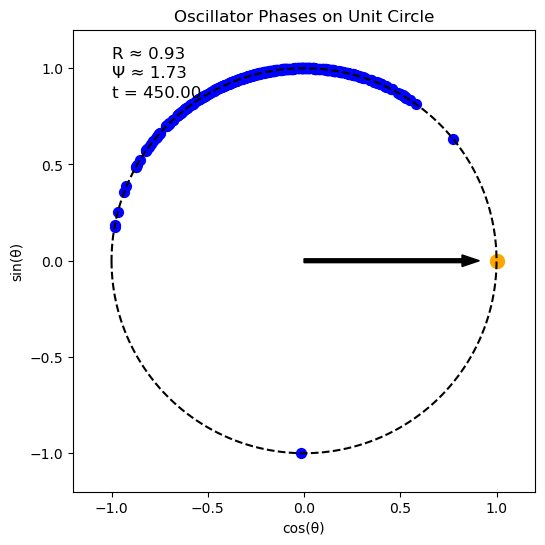

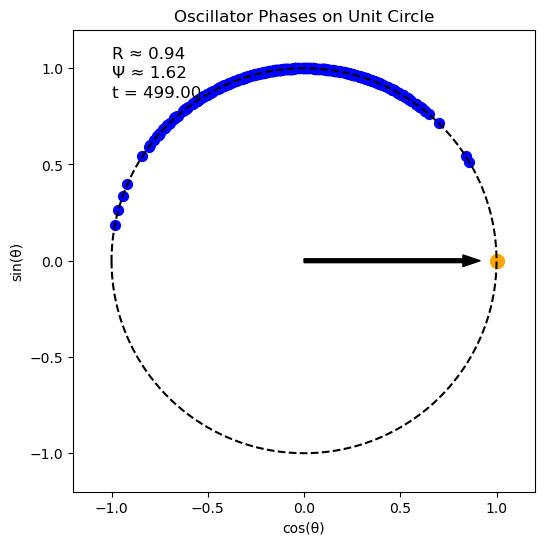

In [38]:
plot_over_time(N, number_time_steps,  theta_history)